# **Note on eigenvalue computation time**
---
<img src="Imperial_logo.png" align = "left" width=200>
<br><br>
 
- Copyright (c) Jack Jacquier, 2026. All rights reserved

- Author: Jack Jacquier <a.jacquier@imperial.ac.uk>

- Platform: Tested on Windows 10 with Python 3.9

`numpy` eigenvalues computation time
---

We study here the computation time of the eigenvalues of a square matrix using `numpy`.
Note that depending on the matrix, faster methods are available, in particular if the matrix has some degrees of sparsity.

In [3]:
from platform import python_version
python_version()

'3.13.5'

In [4]:
import numpy as np
import time
from numpy.linalg import eig
from scipy.sparse.linalg import eigs, eigsh
import matplotlib.pylab as plt

Several packages exist to compute eigenvalues of matrices.
Recall further that, given any square matrix $S$ of dimension $n\times n$ with complex entries, the matrix defined as 
$$
A := \frac{S + S^{\dagger}}{2}
$$
is Hermitian.

In [5]:
N = 6
S = np.random.normal(0., 1., (N,N)) ## We take a matrix X randomly generated

A = (S + S.conj().T)/2.

vals_scipy_sparse, vecs_scipy_sparse = eigsh(A, k=N) ## https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.eigsh.html
vals_scipy, vecs_scipy = eigs(A, k=N) ## https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.eigs.html
vals_numpy, vecs_numpy = eig(A) ## https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

print("*********************")
print("eigsh method: ", np.min(vals_scipy_sparse), vals_scipy_sparse[0])

print("*********************")
print("eigs method: ", np.min(vals_scipy), vals_scipy[0])

print("*********************")
print("eig method: ", np.min(vals_numpy), vals_numpy[0])

*********************
eigsh method:  -1.8838379500562794 -1.8838379500562794
*********************
eigs method:  (-1.883837950056284+0j) (-1.883837950056284+0j)
*********************
eig method:  -1.8838379500562845 -1.8838379500562845


C:\Users\ajacquie\AppData\Local\Temp\ipykernel_38468\2029823218.py:6: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  vals_scipy_sparse, vecs_scipy_sparse = eigsh(A, k=N) ## https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.eigsh.html
C:\Users\ajacquie\AppData\Local\Temp\ipykernel_38468\2029823218.py:7: RuntimeWarning: k >= N - 1 for N * N square matrix. Attempting to use scipy.linalg.eig instead.
  vals_scipy, vecs_scipy = eigs(A, k=N) ## https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.eigs.html


*Warning: eigenvalue outputs may not be sorted...*

#### Checking the computation times (might take time to run)

In [6]:
cTimes_X, cTimes_np, cTimes_eigs, cTimes_eigsh, diffEigs, diffEigsh = [], [], [], [], [], []
nn = range(1000, 10000, 2000)
print("Computation times for eigs, eigsh, np, matrix generation, error in min eigenvalue")

for n in nn:
    t0 = time.time()
    X = np.random.normal(0., 1., (n,n))
    A = (X + X.conj().T)/2.

    _cTimes_X = time.time() - t0
    cTimes_X.append(_cTimes_X) ## To separate the time it takes to generate the matrix
    
    t0 = time.time()
    w_numpy, v_numpy = eig(A)
    _cTimes_np = time.time() - t0
    cTimes_np.append(_cTimes_np)
    
    t0 = time.time()
    w_sparse, v_sparse = eigs(A, k=n)
    _cTimes_eigs = time.time() - t0
    cTimes_eigs.append(_cTimes_eigs)

    t0 = time.time()
    w_sparseh, v_sparseh = eigsh(A, k=n)
    _cTimes_eigsh = time.time() - t0
    cTimes_eigsh.append(_cTimes_eigsh)
    
    diffEigs.append(np.min(w_numpy) - np.min(w_sparse))
    diffEigsh.append(np.min(w_numpy) - np.min(w_sparseh))
    ## to compare the outputs of smallest eigenvalue
    
    print(n, np.round(_cTimes_eigs, 4), np.round(_cTimes_eigsh, 4), np.round(_cTimes_np, 4), np.round(_cTimes_X, 4), diffEigs[-1])

print("********** DONE **********")

Computation times for eigs, eigsh, np, matrix generation, error in min eigenvalue


C:\Users\ajacquie\AppData\Local\Temp\ipykernel_38468\4091452895.py:19: RuntimeWarning: k >= N - 1 for N * N square matrix. Attempting to use scipy.linalg.eig instead.
  w_sparse, v_sparse = eigs(A, k=n)
C:\Users\ajacquie\AppData\Local\Temp\ipykernel_38468\4091452895.py:24: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  w_sparseh, v_sparseh = eigsh(A, k=n)


1000 1.661 0.4482 1.1756 0.0486 (-9.947598300641403e-14+0j)
3000 23.8171 16.1546 20.2878 0.5308 (-4.547473508864641e-13+0j)
5000 87.9562 22.7399 85.8784 3.76 (6.679101716144942e-13+0j)
7000 228.6359 50.6356 212.6006 4.3227 (-1.6768808563938364e-12+0j)
9000 419.259 111.7221 381.8823 6.5152 (3.893774191965349e-12+0j)
********** DONE **********


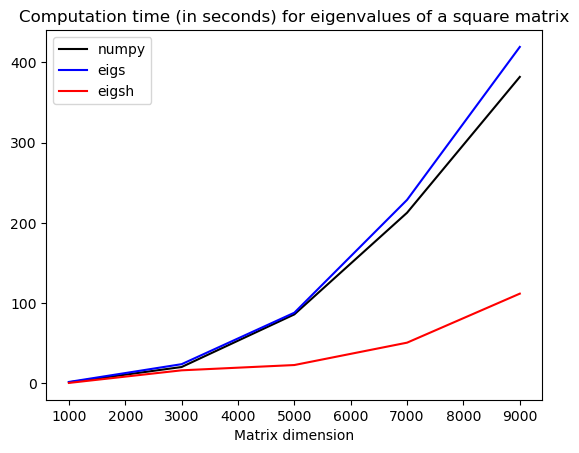

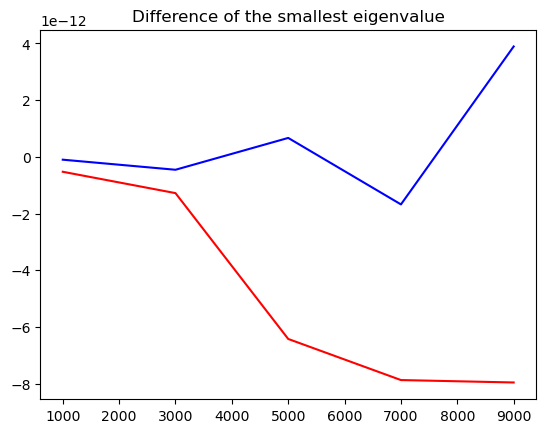

In [8]:
plt.plot(nn, cTimes_np, 'k', label = "numpy")
plt.plot(nn, cTimes_eigs, 'b', label = "eigs")
plt.plot(nn, cTimes_eigsh, 'r', label = "eigsh")
plt.xlabel("Matrix dimension")
plt.legend(loc="best")
plt.title("Computation time (in seconds) for eigenvalues of a square matrix")
#plt.savefig("CompTime.eps")
plt.show()

plt.plot(nn, diffEigs, 'b', label="Between eigs and np")
plt.plot(nn, diffEigsh, 'r', label="Between eigsh and np")
plt.title("Difference of the smallest eigenvalue")
plt.show()